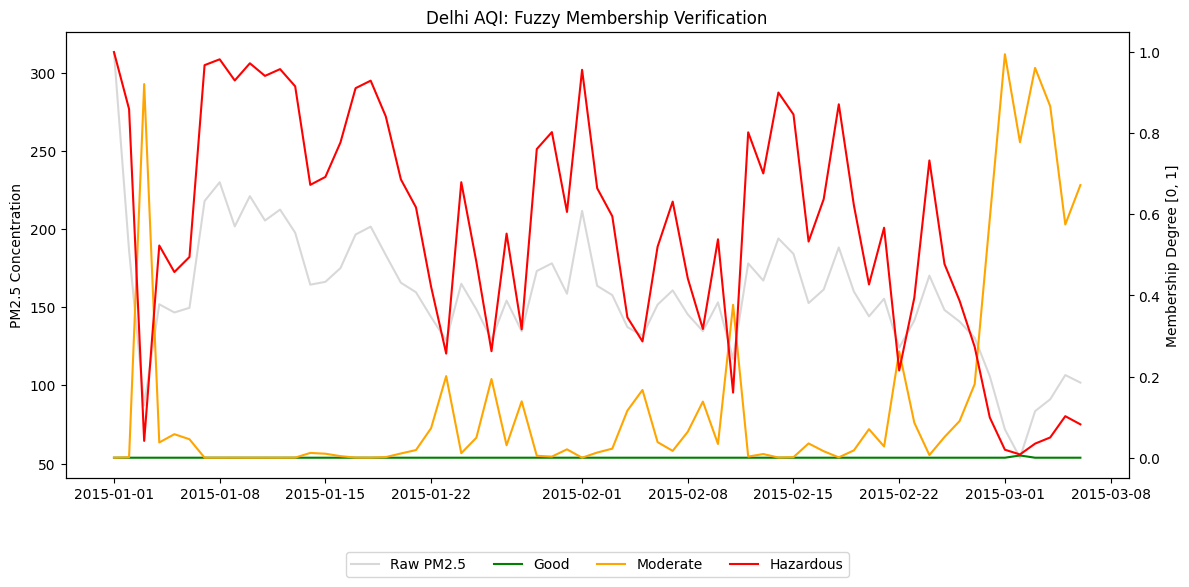

In [28]:
# 1. Initialize the backend for Code-OSS/VS Code
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# 2. Re-load the slice to be safe
df = pd.read_csv('../data/processed/fuzzified_delhi_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
plot_df = df.head(65).copy()

# 3. Create the figure and axes in ONE go
fig, ax1 = plt.subplots(figsize=(12, 6))

# Draw the raw data
ax1.plot(plot_df['Date'], plot_df['PM2.5'], color='gray', alpha=0.3, label='Raw PM2.5')
ax1.set_ylabel('PM2.5 Concentration')

# Create the twin axis on the SAME figure object
ax2 = ax1.twinx()
ax2.plot(plot_df['Date'], plot_df['Fuzzy_PM25_Good'], label='Good', color='green')
ax2.plot(plot_df['Date'], plot_df['Fuzzy_PM25_Moderate'], label='Moderate', color='orange')
ax2.plot(plot_df['Date'], plot_df['Fuzzy_PM25_Hazardous'], label='Hazardous', color='red')

ax2.set_ylabel('Membership Degree [0, 1]')
ax2.set_ylim(-0.05, 1.05)

# Collect the handles and labels from BOTH axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine them into a single legend on ax1 (or ax2)
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, 
           loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), # Places it below the plot for clarity
           ncol=4,                      # Organizes labels in a row
           frameon=True)

plt.title('Delhi AQI: Fuzzy Membership Verification')
plt.tight_layout()
plt.show()